# Census Income Classification Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve, recall_score, precision_score, f1_score
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print("All libraries imported successfully")

All libraries imported successfully


### **1. EDA (Exploratory Data Analysis)**:

In [2]:
# Load column names
with open('/kaggle/input/datasets/nikhilram9/census-income-project/census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines()]

# Load data
df = pd.read_csv('/kaggle/input/datasets/nikhilram9/census-income-project/census-bureau.data', 
                 header=None, 
                 names=columns)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (199523, 42)


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,dividends from stocks,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [3]:
# Check column names
print("Columns:", columns)

Columns: ['age', 'class of worker', 'detailed industry recode', 'detailed occupation recode', 'education', 'wage per hour', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'weight', 'migration code-change in msa', 'migration code-change in reg', 'migration code-move within reg', 'live in this house 1 year ago', 'migration prev res in sunbelt', 'num persons worked for employer', 'family members under 18', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'week

In [4]:
# Check data types
df.dtypes

age                                             int64
class of worker                                object
detailed industry recode                        int64
detailed occupation recode                      int64
education                                      object
wage per hour                                   int64
enroll in edu inst last wk                     object
marital stat                                   object
major industry code                            object
major occupation code                          object
race                                           object
hispanic origin                                object
sex                                            object
member of a labor union                        object
reason for unemployment                        object
full or part time employment stat              object
capital gains                                   int64
capital losses                                  int64
dividends from stocks       

In [5]:
# Check for actual null values
df.isnull().sum()

age                                             0
class of worker                                 0
detailed industry recode                        0
detailed occupation recode                      0
education                                       0
wage per hour                                   0
enroll in edu inst last wk                      0
marital stat                                    0
major industry code                             0
major occupation code                           0
race                                            0
hispanic origin                               874
sex                                             0
member of a labor union                         0
reason for unemployment                         0
full or part time employment stat               0
capital gains                                   0
capital losses                                  0
dividends from stocks                           0
tax filer stat                                  0


In [6]:
# Statistical summary of numerical columns
df.describe()

,age,detailed industry recode,detailed occupation recode,wage per hour,capital gains,capital losses,dividends from stocks,weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,199523.000000,199523.000000,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.426908,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,274.896454,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


In [7]:
# Check class distribution
print(df['label'].value_counts())
print("\nPercentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

Percentage:
label
- 50000.    93.794199
50000+.      6.205801
Name: proportion, dtype: float64


In [8]:
# Statistical summary of categorical columns
df.describe(include='object')

,class of worker,education,enroll in edu inst last wk,marital stat,major industry code,major occupation code,race,hispanic origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,tax filer stat,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,fill inc questionnaire for veteran's admin,label
count,199523,199523,199523,199523,199523,199523,199523,198649,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523,199523
unique,9,17,3,7,24,15,5,9,2,3,6,8,6,6,51,38,8,10,9,10,3,4,5,43,43,43,5,3,2
top,Not in universe,High school graduate,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,Nonfiler,Not in universe,Not in universe,Householder,Householder,?,?,?,Not in universe under 1 year old,?,Not in universe,United-States,United-States,United-States,Native- Born in the United States,Not in universe,- 50000.
freq,100245,48407,186943,86485,100684,100684,167365,171907,103984,180459,193453,123769,75094,183750,183750,53248,75475,99696,99696,99696,101212,99696,144232,159163,160479,176989,176992,197539,187141


In [9]:
# Check all unique values in every categorical column
for col in df.select_dtypes(include='object').columns:
    unique_vals = df[col].unique()
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(unique_vals)


class of worker (9 unique values):
['Not in universe' 'Self-employed-not incorporated' 'Private'
 'Local government' 'Federal government' 'Self-employed-incorporated'
 'State government' 'Never worked' 'Without pay']

education (17 unique values):
['High school graduate' 'Some college but no degree' '10th grade'
 'Children' 'Bachelors degree(BA AB BS)'
 'Masters degree(MA MS MEng MEd MSW MBA)' 'Less than 1st grade'
 'Associates degree-academic program' '7th and 8th grade'
 '12th grade no diploma' 'Associates degree-occup /vocational'
 'Prof school degree (MD DDS DVM LLB JD)' '5th or 6th grade' '11th grade'
 'Doctorate degree(PhD EdD)' '9th grade' '1st 2nd 3rd or 4th grade']

enroll in edu inst last wk (3 unique values):
['Not in universe' 'High school' 'College or university']

marital stat (7 unique values):
['Widowed' 'Divorced' 'Never married' 'Married-civilian spouse present'
 'Separated' 'Married-spouse absent' 'Married-A F spouse present']

major industry code (24 unique values)

In [10]:
# Check for ? values across all columns
for col in df.columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        print(f"{col}: {q_count} '?' values ({q_count/len(df)*100:.1f}%)")

state of previous residence: 708 '?' values (0.4%)
migration code-change in msa: 99696 '?' values (50.0%)
migration code-change in reg: 99696 '?' values (50.0%)
migration code-move within reg: 99696 '?' values (50.0%)
migration prev res in sunbelt: 99696 '?' values (50.0%)
country of birth father: 6713 '?' values (3.4%)
country of birth mother: 6119 '?' values (3.1%)
country of birth self: 3393 '?' values (1.7%)


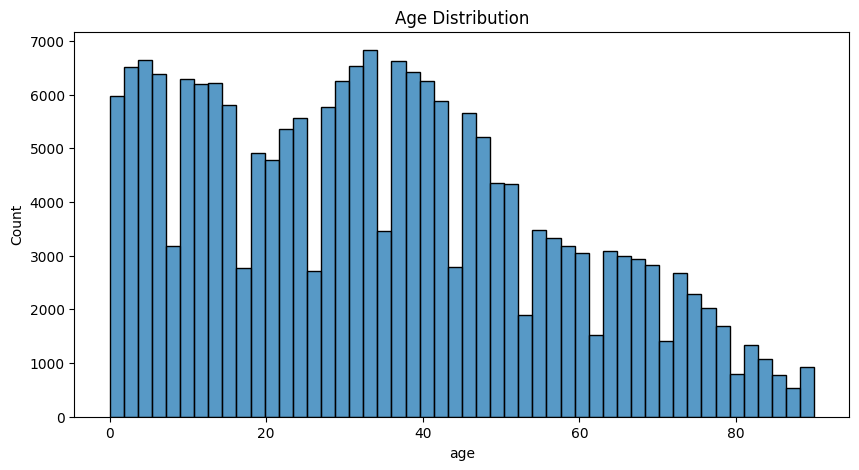

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=50)
plt.title('Age Distribution')
plt.show()

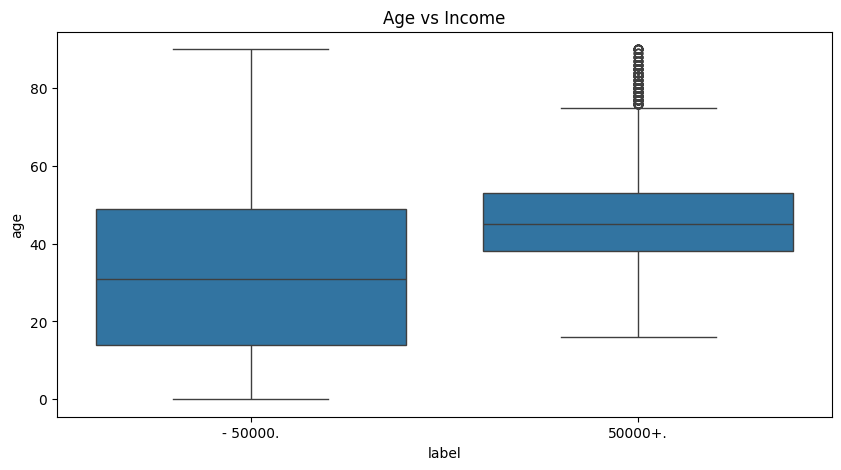

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(x='label', y='age', data=df)
plt.title('Age vs Income')
plt.show()

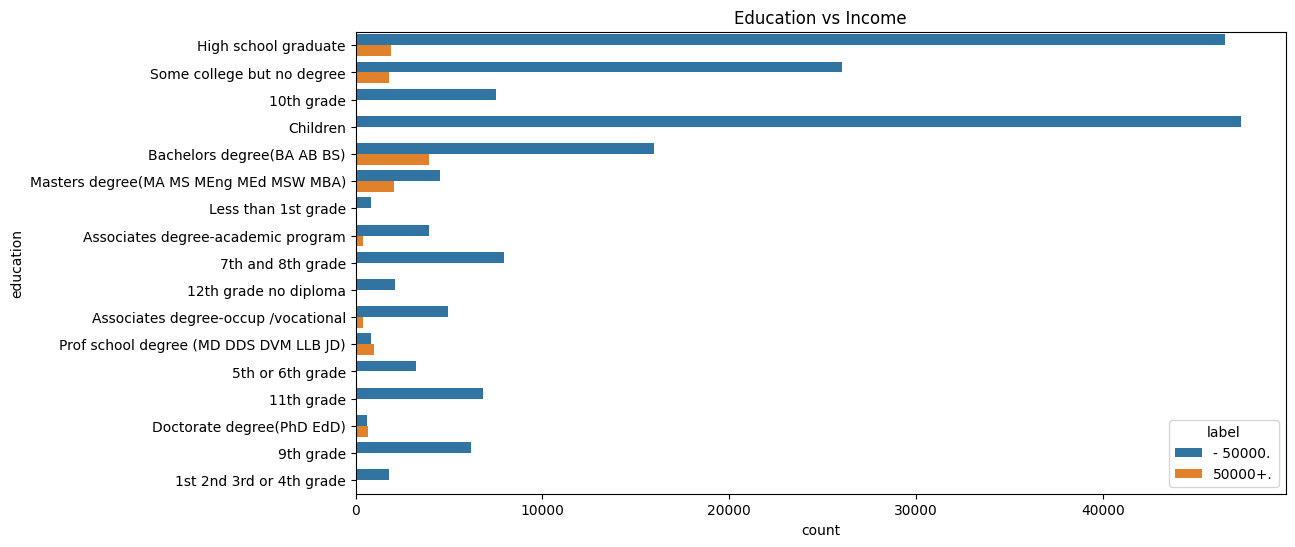

In [13]:
plt.figure(figsize=(12,6))
sns.countplot(y='education', hue='label', data=df)
plt.title('Education vs Income')
plt.show()

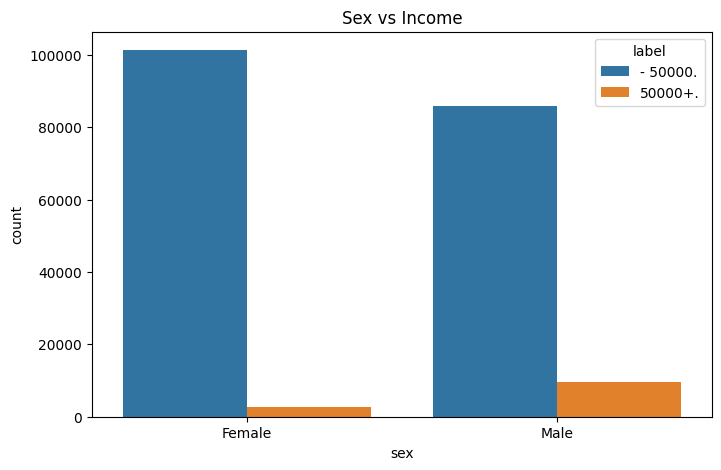

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='sex', hue='label', data=df)
plt.title('Sex vs Income')
plt.show()

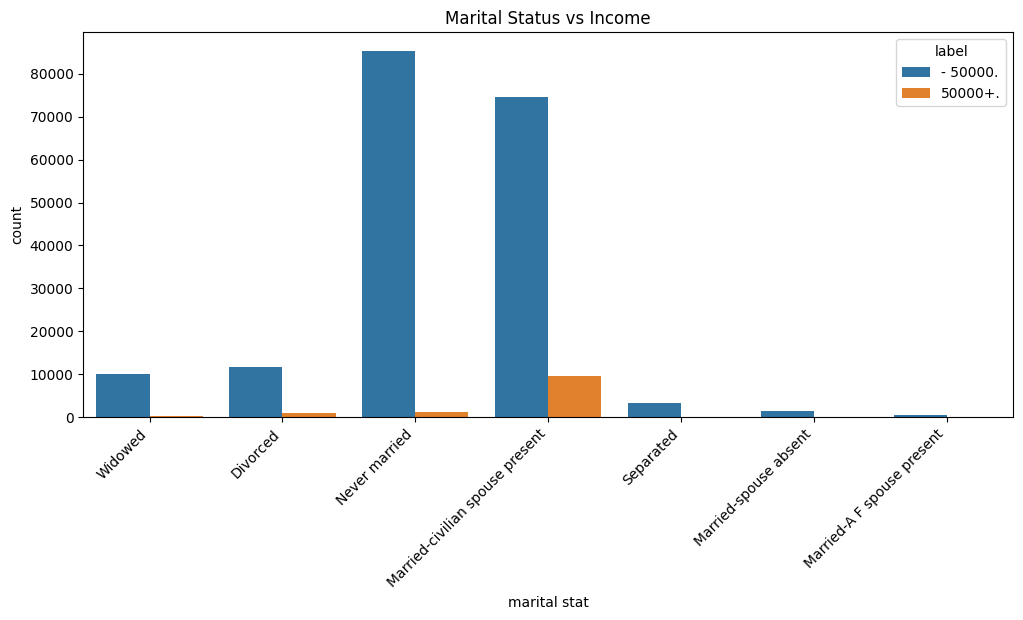

In [15]:
plt.figure(figsize=(12,5))
sns.countplot(x='marital stat', hue='label', data=df)
plt.title('Marital Status vs Income')
plt.xticks(rotation=45, ha='right')
plt.show()

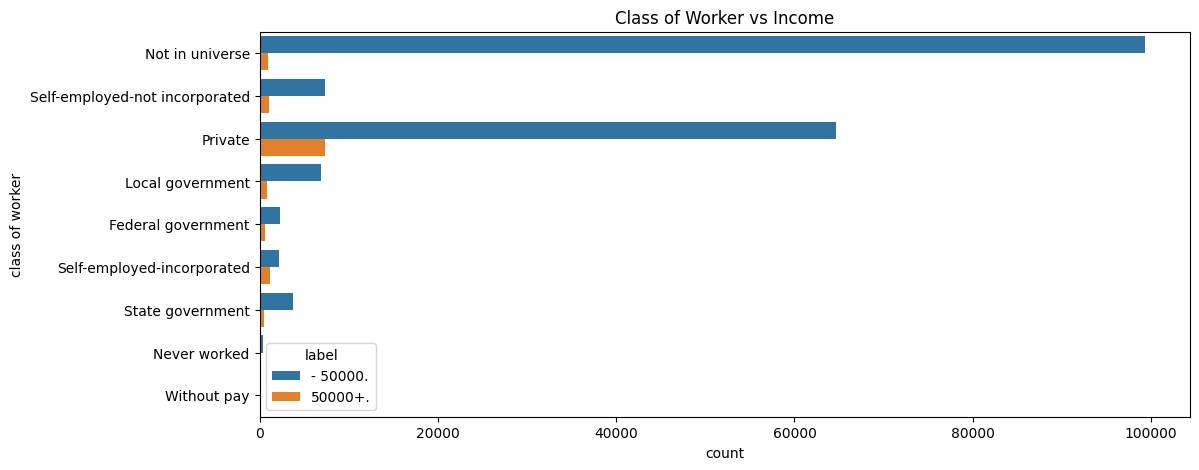

In [16]:
plt.figure(figsize=(12,5))
sns.countplot(y='class of worker', hue='label', data=df)
plt.title('Class of Worker vs Income')
plt.show()

### **2. Data Cleaning:**

In [17]:
# Check how many records are under 18
print(f"Records under 18: {df[df['age'] < 18].shape[0]}")
print(f"Percentage: {df[df['age'] < 18].shape[0] / len(df) * 100:.1f}%")
print("\nLabel distribution for under 18:")
print(df[df['age'] < 18]['label'].value_counts())

Records under 18: 55992
Percentage: 28.1%

Label distribution for under 18:
label
- 50000.    55990
50000+.         2
Name: count, dtype: int64


In [18]:
# Remove under 18 - legally cannot earn full time income
# Only 2 out of 55,992 under-18s earned 50K+ confirming they are noise
df = df[df['age'] >= 18].reset_index(drop=True)
print(f"Dataset shape after removing under 18: {df.shape}")
print("\nNew class distribution:")
print(df['label'].value_counts(normalize=True) * 100)

Dataset shape after removing under 18: (143531, 42)

New class distribution:
label
- 50000.    91.374686
50000+.      8.625314
Name: proportion, dtype: float64


In [19]:
# Drop migration columns - 50% missing values (71,811 ?)
# Drop family members under 18 - zero variance after age filtering (single unique value)
cols_to_drop = [
    'migration code-change in msa',
    'migration code-change in reg', 
    'migration code-move within reg',
    'migration prev res in sunbelt',
    'family members under 18'
]

df = df.drop(columns=cols_to_drop)
print(f"Dataset shape after dropping columns: {df.shape}")

Dataset shape after dropping columns: (143531, 37)


In [20]:
# Encode label: 0 = under 50K, 1 = over 50K
df['label'] = df['label'].map({'- 50000.': 0, '50000+.': 1})
print(df['label'].value_counts())

label
0    131151
1     12380
Name: count, dtype: int64


In [21]:
# Replace ? with Unknown in country and state columns
# These are genuinely unknown values (2-4% missing) - treat as separate category
cols_with_question = [
    'state of previous residence',
    'country of birth father',
    'country of birth mother',
    'country of birth self'
]

for col in cols_with_question:
    df[col] = df[col].replace('?', 'Unknown')

# Handle null values in hispanic origin
df['hispanic origin'] = df['hispanic origin'].fillna('Unknown')

# Verify no missing values remain
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"Remaining ?: {(df == '?').sum().sum()}")

Remaining nulls: 0
Remaining ?: 0


### **3. Train/Test Split:**

In [22]:
# Separate features and target
# Drop weight column - not a feature, used for population sampling only
X = df.drop(columns=['label', 'weight'])
y = df['label']

# Stratify ensures class distribution is preserved in both splits
# Critical for imbalanced dataset - 91.4% vs 8.6%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

Training set: (114824, 35)
Test set: (28707, 35)

Class distribution in training set:
label
0    91.374626
1     8.625374
Name: proportion, dtype: float64


### **4. Preprocessing:**

In [23]:
# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (12): ['age', 'detailed industry recode', 'detailed occupation recode', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks', 'num persons worked for employer', 'own business or self employed', 'veterans benefits', 'weeks worked in year', 'year']

Categorical columns (23): ['class of worker', 'education', 'enroll in edu inst last wk', 'marital stat', 'major industry code', 'major occupation code', 'race', 'hispanic origin', 'sex', 'member of a labor union', 'reason for unemployment', 'full or part time employment stat', 'tax filer stat', 'region of previous residence', 'state of previous residence', 'detailed household and family stat', 'detailed household summary in household', 'live in this house 1 year ago', 'country of birth father', 'country of birth mother', 'country of birth self', 'citizenship', "fill inc questionnaire for veteran's admin"]


In [24]:
# Check unique values for numerical columns
# To identify columns that look numerical but are actually categorical codes
for col in numerical_cols:
    print(f"{col}: {X_train[col].unique()}")

age: [33 37 45 18 32 36 25 30 34 27 46 87 55 53 42 75 50 47 51 54 77 24 39 40
 23 22 43 35 60 70 41 44 59 66 68 71 90 21 38 56 26 89 29 19 85 88 69 48
 63 28 58 57 64 52 80 84 67 62 61 20 31 74 49 83 79 65 76 82 78 73 86 72
 81]
detailed industry recode: [ 0 42 33 39 38 12  4 44 50 48 43  2 34 16 14 21 45 47 40 29  7 35 41 23
 13 37  5 31 22 32 19  6  1  9 24 11 30 25 27 18  3 36 15 49  8 17 46 28
 20 26 51 10]
detailed occupation recode: [ 0  2 35 36 33 32 16  6 22 12 26 14 10 43  4 25 19 28 44 24 31 39 37  1
  9 34  8  3 15 29 41 23 45 11  5 42  7 38 30 40 17 13 18 21 27 20 46]
wage per hour: [   0 1875  525 ... 8300 1987 1078]
capital gains: [    0 15024  2228  1409  7688  4787 34095  2964  8614 99999  3471  7298
  3781  3887  2907  2407  2580  2993  3273  5178  2346  4386 15020   914
   594  1848 11678  5013  2062   991  1055  3103  4650  2885  2538 13550
 10520  3325  3411  4101  2961  3464  1797  1173  4508  2977   401  3908
  3942  2176 27828  2329  6767  4064 14084  2354  6612 

In [25]:
# These columns have numeric codes but represent categories
# own business or self employed: 0,1,2 (category codes)
# veterans benefits: 1,2 (category codes)  
# year: 94,95 (two years only)
# detailed industry/occupation recode: numeric codes for categories
to_categorical = [
    'own business or self employed', 
    'veterans benefits', 
    'year',
    'detailed industry recode',
    'detailed occupation recode'
]

for col in to_categorical:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Recheck column types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numerical columns: 7
Categorical columns: 28


In [26]:
# Numerical pipeline - StandardScaler normalizes numerical features
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical pipeline - OneHotEncoder for tree models
# handle_unknown='ignore' handles rare categories in test set not seen in training
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combined preprocessor
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Calculate class imbalance ratio for XGBoost/LightGBM
scale_pos_weight = int(y_train.value_counts()[0] / y_train.value_counts()[1])
print(f"Scale pos weight: {scale_pos_weight}")
print("Preprocessor defined successfully")

Scale pos weight: 10
Preprocessor defined successfully


### **5. Model Building:**

### 5.1 Logistic Regression (Baseline):

In [27]:
# Baseline model using one-hot encoding
# class_weight='balanced' handles class imbalance automatically
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_lr = baseline_pipeline.predict(X_test)
y_prob_lr = baseline_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression (Baseline):")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression (Baseline):
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     26231
           1       0.33      0.86      0.47      2476

    accuracy                           0.84     28707
   macro avg       0.66      0.85      0.69     28707
weighted avg       0.93      0.84      0.87     28707

ROC-AUC: 0.9239


### 5.2 Random Forest:

In [28]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     26231
           1       0.74      0.40      0.52      2476

    accuracy                           0.94     28707
   macro avg       0.84      0.69      0.74     28707
weighted avg       0.93      0.94      0.93     28707

ROC-AUC: 0.9233


### 5.3 XGBoost:

In [29]:
# XGBoost with one-hot encoding
# scale_pos_weight dynamically calculated from training data to handle imbalance
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_pipeline.fit(X_train, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     26231
           1       0.37      0.85      0.52      2476

    accuracy                           0.86     28707
   macro avg       0.68      0.86      0.72     28707
weighted avg       0.93      0.86      0.89     28707

ROC-AUC: 0.9360


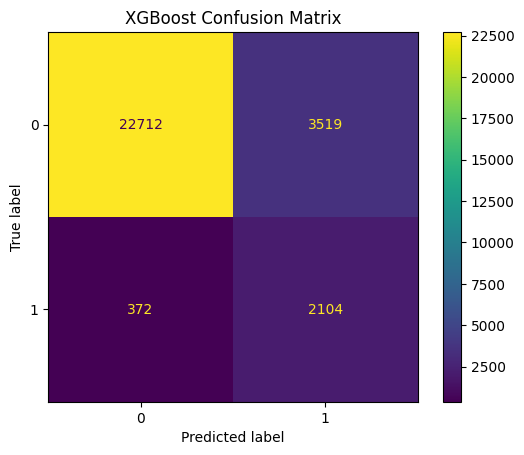

In [30]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title('XGBoost Confusion Matrix')
plt.show()

                                               feature  importance
6                                 weeks worked in year    0.055968
167  major occupation code_Executive admin and mana...    0.033227
175       major occupation code_Professional specialty    0.031985
195                                         sex_Female    0.030763
172                major occupation code_Other service    0.027984
4                                dividends from stocks    0.021615
218                            tax filer stat_Nonfiler    0.018426
128   education_Masters degree(MA MS MEng MEd MSW MBA)    0.016312
129   education_Prof school degree (MD DDS DVM LLB JD)    0.016240
165  major occupation code_Adm support including cl...    0.015632
126                     education_High school graduate    0.013810
216                 tax filer stat_Joint both under 65    0.013646
169  major occupation code_Handlers equip cleaners ...    0.013532
299  detailed household summary in household_Child ...    0.01

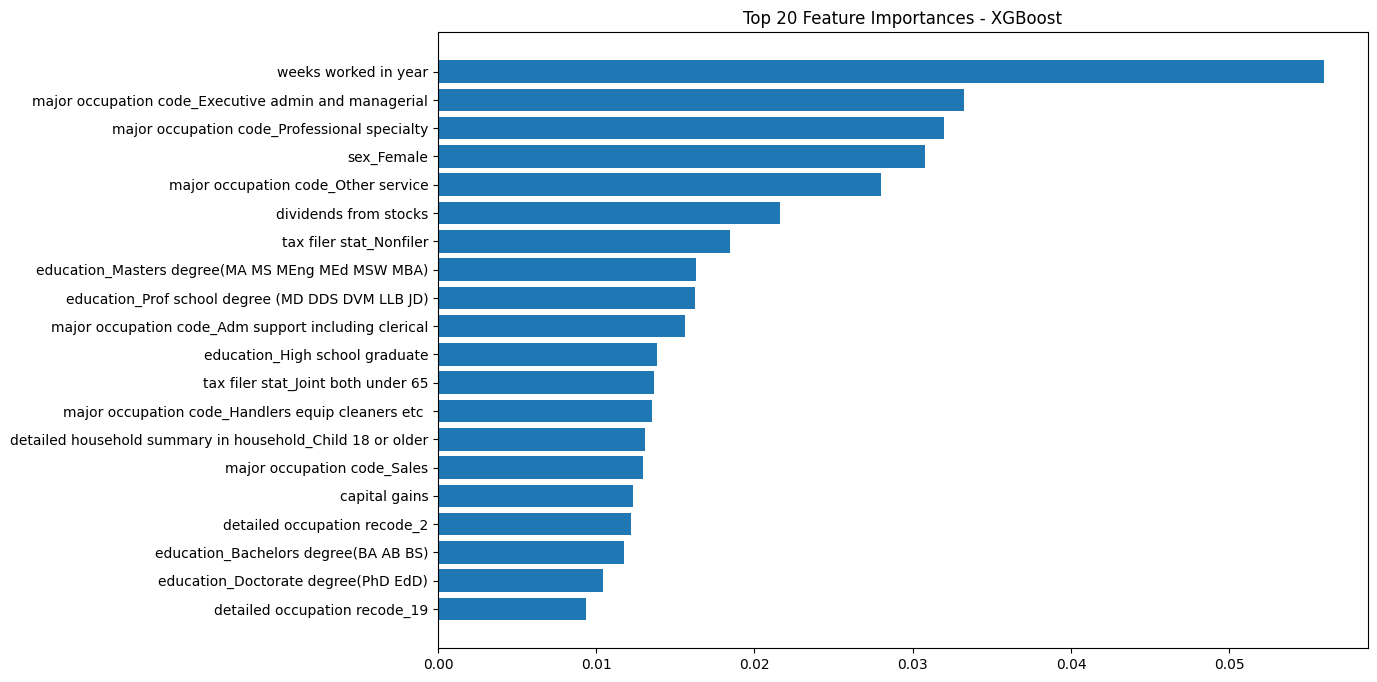

In [31]:
# Extract feature names after one-hot encoding
feature_names = (numerical_cols + 
                 xgb_pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_cols).tolist())

importances = xgb_pipeline.named_steps['classifier'].feature_importances_

# Feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(20))
print(f"\nTotal features: {len(feature_importance_df)}")
print(f"Features with zero importance: {(feature_importance_df['importance'] == 0).sum()}")
print(f"Features with importance < 0.001: {(feature_importance_df['importance'] < 0.001).sum()}")

# Plot top 20
indices = feature_importance_df.head(20).index
plt.figure(figsize=(12,8))
plt.barh(feature_importance_df.loc[indices, 'feature'][::-1], 
         feature_importance_df.loc[indices, 'importance'][::-1])
plt.title('Top 20 Feature Importances - XGBoost')
plt.show()

### 5.4 XGBoost with Target Encoding:

In [32]:
# Target encoding reduces 450+ one-hot features to 35 features
# Encodes each category as its mean target rate (probability of earning 50K+)
# Must fit on training data only to avoid data leakage
xgb_target_pipeline = Pipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols)),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

xgb_target_pipeline.fit(X_train, y_train)
y_pred_xgb_te = xgb_target_pipeline.predict(X_test)
y_prob_xgb_te = xgb_target_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost with Target Encoding:")
print(classification_report(y_test, y_pred_xgb_te))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb_te):.4f}")

XGBoost with Target Encoding:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     26231
           1       0.38      0.85      0.52      2476

    accuracy                           0.87     28707
   macro avg       0.68      0.86      0.72     28707
weighted avg       0.93      0.87      0.89     28707

ROC-AUC: 0.9367


### 5.5 LightGBM:

In [33]:
# LightGBM with target encoding
# num_leaves controls tree complexity - more appropriate than max_depth for LightGBM
# is_unbalance=True handles class imbalance natively
lgbm_pipeline = Pipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols)),
    ('scaler', StandardScaler()),
    ('classifier', LGBMClassifier(
        is_unbalance=True,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        random_state=42,
        verbose=-1
    ))
])

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)
y_prob_lgbm = lgbm_pipeline.predict_proba(X_test)[:, 1]

print("LightGBM:")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92     26231
           1       0.38      0.84      0.53      2476

    accuracy                           0.87     28707
   macro avg       0.68      0.86      0.73     28707
weighted avg       0.93      0.87      0.89     28707

ROC-AUC: 0.9366


### 5.6 CatBoost:

In [34]:
# CatBoost handles categorical features natively - no encoding needed
# auto_class_weights='Balanced' handles class imbalance
catboost_pipeline = Pipeline([
    ('classifier', CatBoostClassifier(
        auto_class_weights='Balanced',
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0,
        cat_features=categorical_cols
    ))
])

catboost_pipeline.fit(X_train, y_train)
y_pred_cb = catboost_pipeline.predict(X_test)
y_prob_cb = catboost_pipeline.predict_proba(X_test)[:, 1]

print("CatBoost:")
print(classification_report(y_test, y_pred_cb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_cb):.4f}")

CatBoost:
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     26231
           1       0.36      0.86      0.50      2476

    accuracy                           0.85     28707
   macro avg       0.67      0.86      0.71     28707
weighted avg       0.93      0.85      0.88     28707

ROC-AUC: 0.9336


### 5.7 Neural Network (MLP):

In [35]:
# MLP with target encoding and standard scaling
# 3 hidden layers: 128 -> 64 -> 32 neurons
# early_stopping prevents overfitting
mlp_pipeline = Pipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols)),
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu',
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    ))
])

mlp_pipeline.fit(X_train, y_train)
y_pred_mlp = mlp_pipeline.predict(X_test)
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

print("Neural Network (MLP):")
print(classification_report(y_test, y_pred_mlp))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp):.4f}")

Neural Network (MLP):
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     26231
           1       0.70      0.46      0.55      2476

    accuracy                           0.94     28707
   macro avg       0.82      0.72      0.76     28707
weighted avg       0.93      0.94      0.93     28707

ROC-AUC: 0.9246


### **6. Hyperparameter Tuning:**

### 6.1 XGBoost Hyperparameter Tuning:

In [36]:
param_dist = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [4, 6, 8],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb_target_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_search.best_estimator_.predict(X_test)
y_prob_xgb_tuned = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")
print("\nTuned XGBoost:")
print(classification_report(y_test, y_pred_xgb_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 200, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9313

Tuned XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     26231
           1       0.39      0.83      0.53      2476

    accuracy                           0.87     28707
   macro avg       0.69      0.85      0.73     28707
weighted avg       0.93      0.87      0.89     28707

ROC-AUC: 0.9372


### 6.2 LightGBM Hyperparameter Tuning (Best Individual Model):

In [37]:
lgbm_param_dist = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [31, 63, 127],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

y_pred_lgbm_tuned = lgbm_search.best_estimator_.predict(X_test)
y_prob_lgbm_tuned = lgbm_search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Best params: {lgbm_search.best_params_}")
print(f"Best CV ROC-AUC: {lgbm_search.best_score_:.4f}")
print("\nTuned LightGBM:")
print(classification_report(y_test, y_pred_lgbm_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm_tuned):.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best params: {'classifier__subsample': 1.0, 'classifier__num_leaves': 63, 'classifier__n_estimators': 200, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}
Best CV ROC-AUC: 0.9323

Tuned LightGBM:
              precision    recall  f1-score   support

           0       0.98      0.86      0.92     26231
           1       0.37      0.86      0.52      2476

    accuracy                           0.86     28707
   macro avg       0.68      0.86      0.72     28707
weighted avg       0.93      0.86      0.89     28707

ROC-AUC: 0.9374


### 6.3 Neural Network (MLP) Hyperparameter Tuning:

In [38]:
mlp_param_dist = {
    'classifier__hidden_layer_sizes': [(64,32), (128,64), (128,64,32), (256,128,64)],
    'classifier__learning_rate_init': [0.001, 0.01, 0.0001],
    'classifier__alpha': [0.0001, 0.001, 0.01]
}

mlp_search = RandomizedSearchCV(
    mlp_pipeline,
    param_distributions=mlp_param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

mlp_search.fit(X_train, y_train)

y_pred_mlp_tuned = mlp_search.best_estimator_.predict(X_test)
y_prob_mlp_tuned = mlp_search.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Best params: {mlp_search.best_params_}")
print(f"Best CV ROC-AUC: {mlp_search.best_score_:.4f}")
print("\nTuned MLP:")
print(classification_report(y_test, y_pred_mlp_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp_tuned):.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'classifier__learning_rate_init': 0.0001, 'classifier__hidden_layer_sizes': (128, 64), 'classifier__alpha': 0.001}
Best CV ROC-AUC: 0.9216

Tuned MLP:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     26231
           1       0.73      0.41      0.53      2476

    accuracy                           0.94     28707
   macro avg       0.84      0.70      0.75     28707
weighted avg       0.93      0.94      0.93     28707

ROC-AUC: 0.9269


### 6.4 MLP with Feature Selection:

In [39]:
# Feature selection using XGBoost importance scores
# Removes features with importance < 0.001 before passing to MLP
# Reduces noise and helps neural network focus on meaningful features
mlp_fs_pipeline = Pipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols)),
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(
        XGBClassifier(
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            eval_metric='logloss'
        ),
        threshold=0.001
    )),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        learning_rate_init=0.0001,
        alpha=0.001,
        max_iter=100,
        random_state=42,
        early_stopping=True
    ))
])

mlp_fs_pipeline.fit(X_train, y_train)
y_pred_mlp_fs = mlp_fs_pipeline.predict(X_test)
y_prob_mlp_fs = mlp_fs_pipeline.predict_proba(X_test)[:, 1]

print("MLP with Feature Selection:")
print(classification_report(y_test, y_pred_mlp_fs))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_mlp_fs):.4f}")

MLP with Feature Selection:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     26231
           1       0.70      0.44      0.54      2476

    accuracy                           0.94     28707
   macro avg       0.83      0.71      0.75     28707
weighted avg       0.93      0.94      0.93     28707

ROC-AUC: 0.9261


### **7. Ensemble: LightGBM + MLP (Best Overall Model):**

In [40]:
# Soft voting ensemble combining diverse models
# LightGBM: best individual model, high recall
# MLP (tuned): high precision, different learning approach
# Soft voting averages probabilities - uses more information than hard voting
tuned_ensemble = Pipeline([
    ('target_enc', TargetEncoder(cols=categorical_cols)),
    ('scaler', StandardScaler()),
    ('classifier', VotingClassifier(
        estimators=[
            ('lgbm', lgbm_search.best_estimator_.named_steps['classifier']),
            ('mlp', mlp_search.best_estimator_.named_steps['classifier'])
        ],
        voting='soft'
    ))
])

tuned_ensemble.fit(X_train, y_train)
y_pred_ensemble = tuned_ensemble.predict(X_test)
y_prob_ensemble = tuned_ensemble.predict_proba(X_test)[:, 1]

print("Ensemble (LightGBM + MLP):")
print(classification_report(y_test, y_pred_ensemble))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ensemble):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ensemble (LightGBM + MLP):
              precision    recall  f1-score   support

           0       0.97      0.95      0.96     26231
           1       0.56      0.68      0.62      2476

    accuracy                           0.93     28707
   macro avg       0.77      0.81      0.79     28707
weighted avg       0.93      0.93      0.93     28707

ROC-AUC: 0.9359


### **8. Threshold Tuning:**

In [41]:
# Find optimal decision threshold that maximizes F1 score
# Default threshold is 0.5 - not optimal for imbalanced datasets
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_ensemble)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_threshold = thresholds[f1_scores.argmax()]

# Apply optimal threshold
y_pred_final = (y_prob_ensemble >= best_threshold).astype(int)

print(f"Optimal threshold: {best_threshold:.4f}")
print("\nFinal Ensemble with Optimal Threshold:")
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_ensemble):.4f}")

Optimal threshold: 0.5382

Final Ensemble with Optimal Threshold:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96     26231
           1       0.61      0.64      0.62      2476

    accuracy                           0.93     28707
   macro avg       0.79      0.80      0.79     28707
weighted avg       0.93      0.93      0.93     28707

ROC-AUC: 0.9359


### **9. Final Model Comparison:**

In [42]:
results = {
    'Model': [
        'Logistic Regression (baseline)',
        'Random Forest',
        'XGBoost (tuned)',
        'LightGBM (tuned)',
        'CatBoost',
        'Neural Network (tuned)',
        'Ensemble LightGBM+MLP',
        'Ensemble + Threshold (Final)'
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb_tuned),
        recall_score(y_test, y_pred_lgbm_tuned),
        recall_score(y_test, y_pred_cb),
        recall_score(y_test, y_pred_mlp_tuned),
        recall_score(y_test, y_pred_ensemble),
        recall_score(y_test, y_pred_final)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb_tuned),
        precision_score(y_test, y_pred_lgbm_tuned),
        precision_score(y_test, y_pred_cb),
        precision_score(y_test, y_pred_mlp_tuned),
        precision_score(y_test, y_pred_ensemble),
        precision_score(y_test, y_pred_final)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb_tuned),
        f1_score(y_test, y_pred_lgbm_tuned),
        f1_score(y_test, y_pred_cb),
        f1_score(y_test, y_pred_mlp_tuned),
        f1_score(y_test, y_pred_ensemble),
        f1_score(y_test, y_pred_final)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb_tuned),
        roc_auc_score(y_test, y_prob_lgbm_tuned),
        roc_auc_score(y_test, y_prob_cb),
        roc_auc_score(y_test, y_prob_mlp_tuned),
        roc_auc_score(y_test, y_prob_ensemble),
        roc_auc_score(y_test, y_prob_ensemble) # same as above - ROC-AUC is threshold-independent
    ]
}

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

                         Model   Recall  Precision       F1  ROC-AUC
              LightGBM (tuned) 0.855008   0.372187 0.518618 0.937353
               XGBoost (tuned) 0.830775   0.390767 0.531525 0.937210
         Ensemble LightGBM+MLP 0.678110   0.563045 0.615244 0.935851
  Ensemble + Threshold (Final) 0.638934   0.606595 0.622345 0.935851
                      CatBoost 0.863893   0.355729 0.503946 0.933562
        Neural Network (tuned) 0.414378   0.727144 0.527914 0.926947
Logistic Regression (baseline) 0.857431   0.326716 0.473145 0.923927
                 Random Forest 0.396607   0.736684 0.515621 0.923288


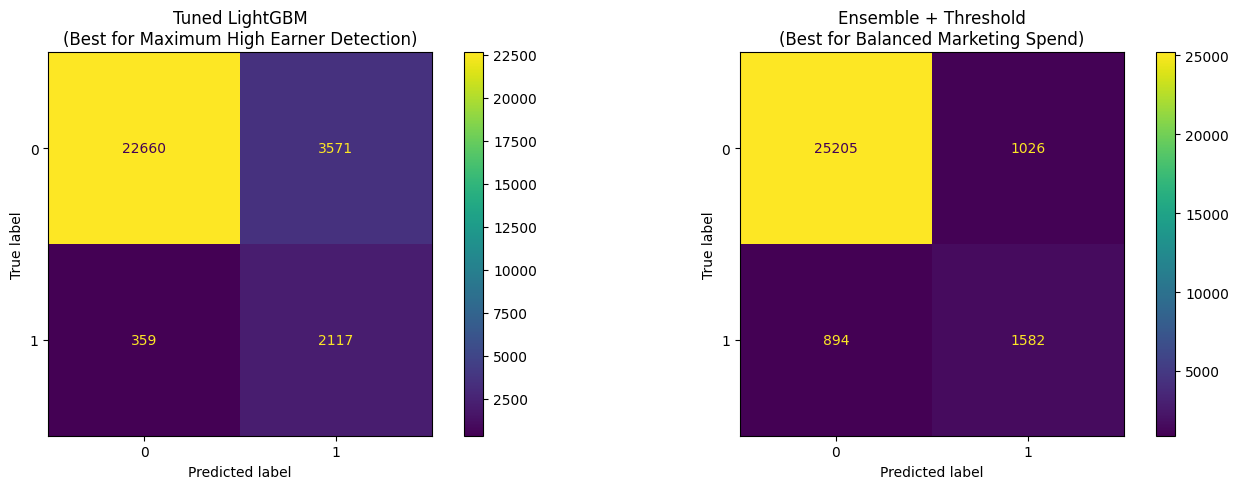

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lgbm_tuned, ax=axes[0]
)
axes[0].set_title('Tuned LightGBM\n(Best for Maximum High Earner Detection)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, ax=axes[1]
)
axes[1].set_title('Ensemble + Threshold\n(Best for Balanced Marketing Spend)')

plt.tight_layout()
plt.show()